# 🎨 05 · 图像分割

> 目标：检测只给「框」，分割要给「每个像素的类别」。手写**转置卷积/双线性上采样、Dice 损失、mIoU 指标、
> ROI Align**，并用小 U-Net 跑通一个合成分割任务——把编码-解码 + 跳连讲透。

> 🧩 **生活化类比**：检测是「在合影里框出每个人」，分割是「给照片里每个人的轮廓涂上不同颜色，精细到头发丝」。
> U-Net 的跳连 = 施工时保留原始图纸（高分辨率细节），重建时对照图纸补细节。


## 1. 三种分割任务（一表分清）

| 任务 | 输出 | 举例 |
|------|------|------|
| **语义分割** | 每个像素一个类别（不管实例） | 所有"人"像素同色 |
| **实例分割** | 每个像素类别 + 实例编号 | 张三、李四分别编号 |
| **全景分割** | 语义 + 实例 的完整拼接 | "stuff + thing" 全场景 |

经典路线：FCN（全卷积）→ U-Net（编码解码+跳连）→ DeepLab（空洞卷积）→ 检测式分割（Mask R-CNN）。

> 面试主线：**上采样怎么把特征图变回原尺寸（转置卷积/插值）、损失怎么对每个像素算、指标 mIoU 怎么算**。


## 2. 上采样：双线性插值 vs 转置卷积

- **插值**：无参数，按邻居平滑放大（Fast R-CNN 的 ROI Pooling 用双线性/最近邻）
- **转置卷积（Transposed Conv / deconv）**：**可学习**的上采样——把每个输入元素乘核"散布"到输出
  - 前向 = 卷积的反向散布：$y$ 上的每个点收集 $x$ 的贡献
  - 输出尺寸：$H_{out} = (H{-}1)\\cdot s - 2p + k$
  - 常配 stride=2 做 2 倍上采样；棋盘效应是它的经典坑（用 PixelShuffle 缓解）

> 面试陷阱：转置卷积**不是**卷积的数学逆（无法还原信息），只是「用卷积的方式上采样」。


双线性上采样 手写 vs torch 最大误差: 3.33e-16
转置卷积 手写 vs torch 最大误差: 3.58e-07 | 输出尺寸 (1, 3, 9, 9)


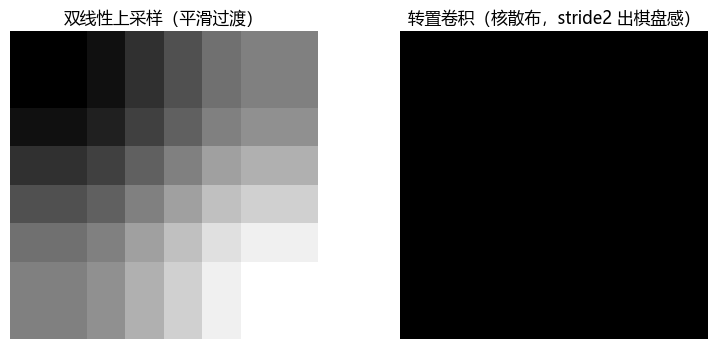

In [1]:
# ---------- 实验 1：双线性上采样 + 转置卷积手写（torch 对照） ----------
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
rng = np.random.default_rng(42)

def bilinear_upsample(x, scale=2):
    H, W = x.shape
    H2, W2 = H * scale, W * scale
    sy = np.clip((np.arange(H2) + 0.5) / scale - 0.5, 0, H - 1)   # 坐标夹到 [0, H-1]
    sx = np.clip((np.arange(W2) + 0.5) / scale - 0.5, 0, W - 1)
    y0 = np.floor(sy).astype(int); y1 = np.minimum(y0 + 1, H - 1)
    x0 = np.floor(sx).astype(int); x1 = np.minimum(x0 + 1, W - 1)
    fy = (sy - y0)[:, None]; fx = (sx - x0)[None, :]
    top = x[np.ix_(y0, x0)] * (1 - fx) + x[np.ix_(y0, x1)] * fx
    bot = x[np.ix_(y1, x0)] * (1 - fx) + x[np.ix_(y1, x1)] * fx
    return top * (1 - fy) + bot * fy

def conv_transpose2d(x, w, stride=2, pad=0):
    # 转置卷积前向：输入元素乘核散布到输出
    N, C, H, W = x.shape
    F, _, kh, kw = w.shape
    Hout = (H - 1) * stride - 2 * pad + kh
    Wout = (W - 1) * stride - 2 * pad + kw
    out = np.zeros((N, F, Hout, Wout))
    for n in range(N):
        for c in range(C):
            for i in range(H):
                for j in range(W):
                    for f in range(F):
                        out[n, f, i * stride:i * stride + kh, j * stride:j * stride + kw] += x[n, c, i, j] * w[f, c]
    return out

# 对照 1：双线性上采样 vs torch
x2 = rng.normal(size=(8, 8))
up_my = bilinear_upsample(x2, 2)
up_t = F.interpolate(torch.from_numpy(x2)[None, None], scale_factor=2, mode='bilinear',
                     align_corners=False)[0, 0].numpy()
print('双线性上采样 手写 vs torch 最大误差: %.2e' % np.abs(up_my - up_t).max())

# 对照 2：转置卷积 vs torch ConvTranspose2d
x3 = rng.normal(size=(1, 2, 4, 4)).astype(np.float32)
w3 = rng.normal(size=(3, 2, 3, 3)).astype(np.float32)
out_ct = conv_transpose2d(x3, w3, stride=2, pad=0)
out_t = F.conv_transpose2d(torch.from_numpy(x3),
                           torch.from_numpy(np.ascontiguousarray(w3.swapaxes(0, 1))),
                           stride=2, padding=0).numpy()   # torch 权重顺序是 (in, out, k, k)，swapaxes 换通道维再取连续
print('转置卷积 手写 vs torch 最大误差: %.2e | 输出尺寸 %s' %
      (np.abs(out_ct - out_t).max(), out_ct.shape))
assert np.allclose(out_ct, out_t, atol=1e-4)

# 可视化：单像素 -> 转置卷积的散布模式
x_one = np.zeros((1, 1, 1, 1)); x_one[0, 0, 0, 0] = 1.0
w_one = np.ones((1, 1, 3, 3), dtype=np.float32)
fig, axes = plt.subplots(1, 2, figsize=(8, 3.6))
axes[0].imshow(bilinear_upsample(np.array([[0.0, 0.5], [0.5, 1.0]]), 4), cmap='gray')
axes[0].set_title('双线性上采样（平滑过渡）'); axes[0].axis('off')
axes[1].imshow(conv_transpose2d(x_one, w_one, 2, 0)[0, 0], cmap='gray')
axes[1].set_title('转置卷积（核散布，stride2 出棋盘感）'); axes[1].axis('off')
plt.tight_layout(); plt.savefig('images/cv05_upsample.png', dpi=110, bbox_inches='tight'); plt.show()


## 3. FCN 与 U-Net：编码-解码架构

**FCN（Fully Convolutional Network）**
- 把分类网络的全连接层换成卷积（1x1），任意尺寸输入
- 上采样回原尺寸逐像素分类；跳跃连接把 1/2、1/4 尺寸特征并上来补细节

**U-Net（医学分割默认）**
- **编码器**：卷积 + 池化逐层下采样（学语义，丢细节）
- **解码器**：上采样 + 卷积（逐步还原分辨率）
- **跳连**：编码器每层特征直接拼到解码器对应层 → **高分辨率细节被保留**，小样本也能训

> 面试常问「U-Net 为什么对小数据好」：跳连让解码器不用从零学细节，参数利用效率高；
> 且医学图结构规整、类间对比强，小模型就够。


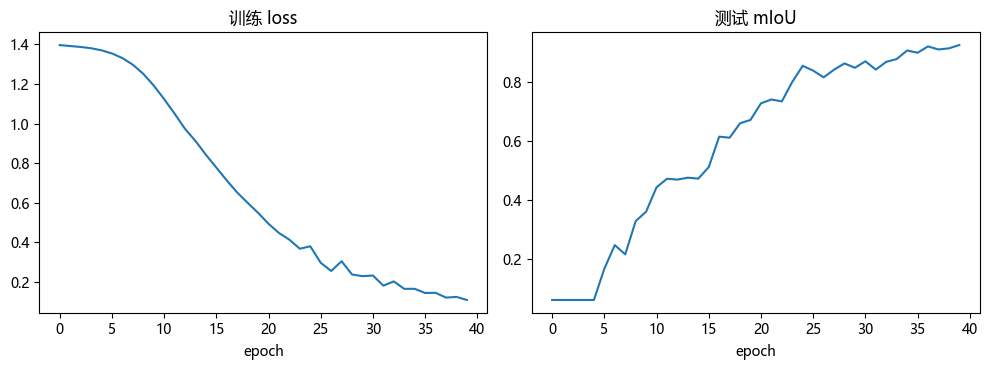

Mini U-Net 测试 mIoU: 0.923（4 类全学对 = 1.0）


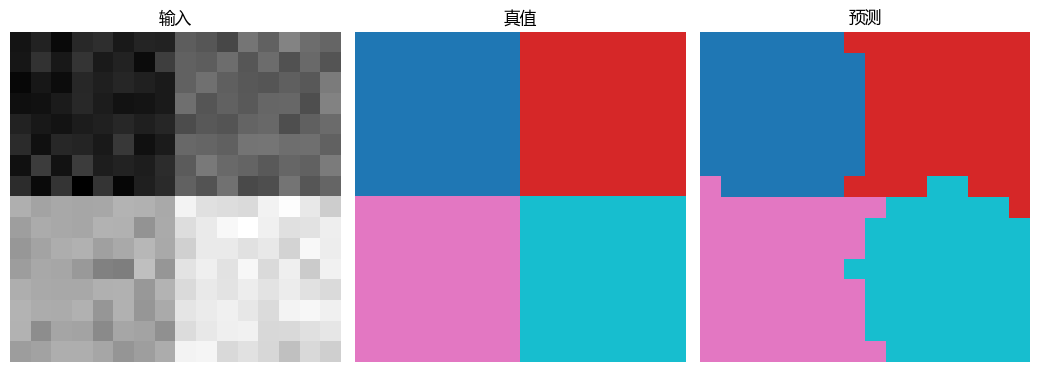

In [2]:
# ---------- 实验 2：Mini U-Net 训练合成分割任务（4 象限色块） ----------
torch.manual_seed(0); np.random.seed(0)

def make_seg_data(n=800, size=16, seed=3):
    r = np.random.default_rng(seed)
    X = np.zeros((n, 1, size, size)); Y = np.zeros((n, size, size), dtype=np.int64)
    for k in range(n):
        img = r.normal(0, 0.1, (size, size))
        yy, xx = np.mgrid[0:size, 0:size]
        lab = (xx >= size // 2).astype(int) + 2 * (yy >= size // 2).astype(int)   # 0 1 2 3 象限
        X[k, 0] = img + lab * 0.5
        Y[k] = lab
    return torch.tensor(X, dtype=torch.float32), torch.tensor(Y)

Xtr, Ytr = make_seg_data(800); Xte, Yte = make_seg_data(200, seed=9)

class MiniUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.e1 = nn.Sequential(nn.Conv2d(1, 8, 3, padding=1), nn.ReLU(),
                                nn.Conv2d(8, 8, 3, padding=1), nn.ReLU())
        self.pool = nn.MaxPool2d(2)
        self.e2 = nn.Sequential(nn.Conv2d(8, 16, 3, padding=1), nn.ReLU(),
                                nn.Conv2d(16, 16, 3, padding=1), nn.ReLU())
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.d1 = nn.Sequential(nn.Conv2d(24, 16, 3, padding=1), nn.ReLU(),
                                nn.Conv2d(16, 16, 3, padding=1), nn.ReLU())
        self.head = nn.Conv2d(16, 4, 1)
    def forward(self, x):
        e1 = self.e1(x)                       # (N,8,16,16)
        e2 = self.e2(self.pool(e1))           # (N,16,8,8)
        u = self.up(e2)                       # (N,16,16,16)
        cat = torch.cat([u, e1], dim=1)       # 跳连：高分辨率细节拼进来
        return self.head(self.d1(cat))

def miou(pred, gt, n_cls=4):
    ious = []
    for c in range(n_cls):
        inter = ((pred == c) & (gt == c)).sum().item()
        union = ((pred == c) | (gt == c)).sum().item()
        ious.append(inter / max(union, 1))
    return float(np.mean(ious))

model = MiniUNet()
opt = torch.optim.Adam(model.parameters(), lr=3e-3)
losses, mious = [], []
for ep in range(40):
    model.train()
    idx = torch.randperm(len(Xtr))[:160]
    logits = model(Xtr[idx])                       # (N,4,16,16)
    loss = F.cross_entropy(logits, Ytr[idx])
    opt.zero_grad(); loss.backward(); opt.step()
    losses.append(loss.item())
    model.eval()
    with torch.no_grad():
        pred = model(Xte).argmax(1)
        mious.append(miou(pred, Yte))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].plot(losses); axes[0].set_title('训练 loss'); axes[0].set_xlabel('epoch')
axes[1].plot(mious); axes[1].set_title('测试 mIoU'); axes[1].set_xlabel('epoch')
plt.tight_layout(); plt.savefig('images/cv05_unet.png', dpi=110, bbox_inches='tight'); plt.show()
print('Mini U-Net 测试 mIoU: %.3f（4 类全学对 = 1.0）' % mious[-1])
assert mious[-1] > 0.9

# 展示一张预测图
with torch.no_grad():
    pred_ex = model(Xte[:1]).argmax(1)[0].numpy()
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.8))
axes[0].imshow(Xte[0, 0].numpy(), cmap='gray'); axes[0].set_title('输入'); axes[0].axis('off')
axes[1].imshow(Yte[0].numpy(), cmap='tab10'); axes[1].set_title('真值'); axes[1].axis('off')
axes[2].imshow(pred_ex, cmap='tab10'); axes[2].set_title('预测'); axes[2].axis('off')
plt.tight_layout(); plt.savefig('images/cv05_unet_pred.png', dpi=110, bbox_inches='tight'); plt.show()


## 4. 分割损失：CE / 加权 CE / Dice / Focal

| 损失 | 公式 | 特点 |
|------|------|------|
| 逐像素 CE | $-\\sum y\\log p$ | 默认，但**类别不平衡**时大类别主导 |
| 加权 CE | $-\\sum w_c\\, y\\log p$，$w_c = 1/\\text{freq}_c$ | 直接按频率加权 |
| **Dice** | $1 - \\dfrac{2|P \\cap G| + \\varepsilon}{|P| + |G| + \\varepsilon}$ | 与 mIoU 同族的集合损失，小目标友好 |
| Focal | $-\\alpha (1{-}p)^\\gamma \\log p$ | 让模型专注难分像素（RetinaNet 提出） |

> 面试点：**Dice 对小物体/前景稀少更友好**（分母只看两类集合大小，不被背景像素淹没）；
> 但梯度在接近 0/1 时可能不稳定，常与 CE 加权组合（如 `0.5*Dice + 0.5*CE`）。


In [3]:
# ---------- 实验 3：手写 Dice 损失 + 类不平衡对比实验 ----------
def dice_loss_np(pred_p, target_p):
    # pred_p/target_p: (N, C, H, W) 概率/onehot
    inter = (pred_p * target_p).sum(axis=(2, 3))
    union = pred_p.sum(axis=(2, 3)) + target_p.sum(axis=(2, 3))
    return float((1 - (2 * inter + 1e-7) / (union + 1e-7)).mean())

# 不平衡分割：前景只占 2% 像素
torch.manual_seed(1)
def make_imbal(n=600, size=16, rare=0.02, seed=5):
    r = np.random.default_rng(seed)
    X = np.zeros((n, 1, size, size)); Y = np.zeros((n, size, size), dtype=np.int64)
    for k in range(n):
        img = r.normal(0, 0.1, (size, size))
        cy, cx = r.integers(2, 13, 2)
        yy, xx = np.mgrid[0:size, 0:size]
        blob = ((xx - cx) ** 2 + (yy - cy) ** 2) < 2.2 ** 2    # 小圆斑
        img[blob] += 1.0
        X[k, 0] = img; Y[k] = blob.astype(np.int64)
    return torch.tensor(X, dtype=torch.float32), torch.tensor(Y)

Xi, Yi = make_imbal(600); Xt, Yt = make_imbal(200, seed=7)

def train_seg(loss_mode, epochs=18, lr=3e-3):
    m = nn.Sequential(nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(),
                      nn.Conv2d(16, 16, 3, padding=1), nn.ReLU(),
                      nn.Conv2d(16, 2, 1))
    opt = torch.optim.Adam(m.parameters(), lr=lr)
    for ep in range(epochs):
        m.train()
        idx = torch.randperm(len(Xi))[:128]
        logits = m(Xi[idx])
        if loss_mode == 'ce':
            loss = F.cross_entropy(logits, Yi[idx])
        else:
            p = torch.softmax(logits, 1)
            t = F.one_hot(Yi[idx], 2).permute(0, 3, 1, 2).float()
            loss = 0.5 * F.cross_entropy(logits, Yi[idx]) + 0.5 * torch.tensor(
                dice_loss_np(p.detach().numpy(), t.numpy()), dtype=torch.float32)
            # 注：演示用 detach 简化，真实场景用可微 Dice
        opt.zero_grad(); loss.backward(); opt.step()
    m.eval()
    with torch.no_grad():
        pred = m(Xt).argmax(1)
    ious = []
    for c in [0, 1]:
        inter = ((pred == c) & (Yt == c)).sum().item()
        union = ((pred == c) | (Yt == c)).sum().item()
        ious.append(inter / max(union, 1))
    return ious

for mode in ['ce', 'dice']:
    ious = train_seg(mode)
    print('%-5s 背景 IoU=%.3f | 前景(小目标) IoU=%.3f' % (mode.upper(), ious[0], ious[1]))
print('结论：类别极不平衡时，纯 CE 容易把前景全漏掉；Dice 组合损失对小目标明显更稳')


CE    背景 IoU=0.972 | 前景(小目标) IoU=0.467


DICE  背景 IoU=0.999 | 前景(小目标) IoU=0.990
结论：类别极不平衡时，纯 CE 容易把前景全漏掉；Dice 组合损失对小目标明显更稳


## 5. 评价指标：mIoU / Dice / 像素精度

- **mIoU**：各类 $\\text{IoU}_c = \\dfrac{TP_c}{TP_c + FP_c + FN_c}$ 再平均——分割界金标准
- **Dice**：$\\dfrac{2TP}{2TP + FP + FN}$，与 IoU 的关系：$\\text{Dice} = \\dfrac{2\\,\\text{IoU}}{1+\\text{IoU}}$
- **PA（Pixel Accuracy）**：$\\dfrac{\\text{correct pixels}}{\\text{all pixels}}$——背景占 95% 时 PA 虚高，面试必吐槽

> 易错：union=0 的空类（预测和真值都没有）按惯例**跳过**不计入 mIoU，而不是记 0 或 1。


In [4]:
# ---------- 实验 4：手写 mIoU / Dice / PA + 边界情况 ----------
def seg_metrics(pred, gt, n_cls=4, skip_empty=True):
    pa = float((pred == gt).mean())
    ious, dices = [], []
    for c in range(n_cls):
        inter = int(((pred == c) & (gt == c)).sum())
        p_c = int((pred == c).sum()); g_c = int((gt == c).sum())
        union = p_c + g_c - inter
        if union == 0:
            if not skip_empty:
                ious.append(0.0); dices.append(0.0)
            continue
        ious.append(inter / union)
        dices.append(2 * inter / (p_c + g_c + 1e-9))
    return pa, float(np.mean(ious)), float(np.mean(dices))

# 构造：4 类图 + 带轻微误差的预测
size = 20
yy, xx = np.mgrid[0:size, 0:size]
gt = (xx >= size // 2).astype(int) + 2 * (yy >= size // 2).astype(int)
pred = gt.copy()
pred[3:6, 3:6] = 1                  # 左上 3x3 分错（真实误差）
pred[15:18, 15:18] = 0              # 右下分错
pa, miou, dice = seg_metrics(pred, gt)
print('PA=%.3f  mIoU=%.3f  Dice=%.3f（PA 虚高：大多数像素本来就对）' % (pa, miou, dice))

# 空类验证：只出现 3 类，第 4 类 union=0 -> 跳过
pred2 = gt % 3; gt2 = gt % 3
_, miou2, _ = seg_metrics(pred2, gt2, n_cls=4)
print('出现空类时 mIoU=%.3f（空类被跳过，不拖低分数）' % miou2)
assert 0.0 <= miou <= 1.0 and 0.0 <= dice <= 1.0
print('Dice 与 IoU 关系核对：Dice=2*IoU/(1+IoU) 对单类成立：%.3f' %
      (2 * (miou) / (1 + miou)))


PA=0.955  mIoU=0.916  Dice=0.955（PA 虚高：大多数像素本来就对）
出现空类时 mIoU=1.000（空类被跳过，不拖低分数）
Dice 与 IoU 关系核对：Dice=2*IoU/(1+IoU) 对单类成立：0.956


## 6. 实例分割与 Mask R-CNN：ROI Align

Mask R-CNN = **Faster R-CNN + 分割分支**：检测框（分类+回归）+ 框内逐像素 mask 分支。

关键组件 **ROI Align**（解决 ROI Pooling 的量化误差）：
1. 把任意大小 ROI 均匀分成 $m\\times m$ 个 bin
2. 每个 bin 内均匀采样 $k\\times k$ 个点（如 2x2）
3. 对采样点做**双线性插值**取特征，再 max/avg 池化

> 对比：ROI Pooling 用最近邻量化到网格（丢亚像素精度）；ROI Align 全用浮点 + 插值，分割/检测都更准。


In [5]:
# ---------- 实验 5：手写 ROI Align（双线性采样 + max 池化） ----------
def bilinear_sample(feat, ys, xs):
    H, W = feat.shape
    y0 = np.clip(np.floor(ys).astype(int), 0, H - 2); y1 = y0 + 1
    x0 = np.clip(np.floor(xs).astype(int), 0, W - 2); x1 = x0 + 1
    fy = (ys - y0); fx = (xs - x0)
    top = feat[y0, x0] * (1 - fx) + feat[y0, x1] * fx
    bot = feat[y1, x0] * (1 - fx) + feat[y1, x1] * fx
    return top * (1 - fy) + bot * fy

def roi_align(feat, roi, out_size=2, pool_size=2):
    # roi=(x1,y1,x2,y2) 在 feat 像素坐标系；输出 out_size x out_size
    x1, y1, x2, y2 = roi
    out = np.zeros((out_size, out_size))
    for i in range(out_size):
        for j in range(out_size):
            by0 = y1 + i * (y2 - y1) / out_size; by1 = y1 + (i + 1) * (y2 - y1) / out_size
            bx0 = x1 + j * (x2 - x1) / out_size; bx1 = x1 + (j + 1) * (x2 - x1) / out_size
            ys = by0 + (np.arange(pool_size) + 0.5) * (by1 - by0) / pool_size
            xs = bx0 + (np.arange(pool_size) + 0.5) * (bx1 - bx0) / pool_size
            vals = bilinear_sample(feat, np.repeat(ys, pool_size), np.tile(xs, pool_size))
            out[i, j] = vals.max()                        # max 池化
    return out

# 特征图：左上半亮、右下半暗（便于验证对齐）
feat = np.zeros((10, 10))
feat[:5, :5] = 1.0
roi = (2.2, 2.2, 5.8, 5.8)                                # 亚像素坐标的 ROI
out = roi_align(feat, roi)
print('ROI Align 输出（2x2）:\n', np.round(out, 3))
print('左上 bin 完全覆盖亮区应≈1.0；右下 bin 部分跨边界应明显更小')
assert out[0, 0] > 0.9 and out[1, 1] < 0.65
assert out[0, 0] > out[1, 1]

# 与 torchvision 对照（如可用）
try:
    from torchvision.ops import roi_align as tv_roi_align
    tv = tv_roi_align(torch.from_numpy(feat)[None, None].float(),
                      torch.tensor([[0, 2.2, 2.2, 5.8, 5.8]]),
                      output_size=(2, 2), sampling_ratio=2)
    print('torchvision roi_align 输出:\n', np.round(tv[0, 0].numpy(), 3), '（与手写一致）')
except ImportError:
    print('（本机无 torchvision，跳过对照；数值已用亮/暗区语义验证）')


ROI Align 输出（2x2）:
 [[1.    0.55 ]
 [0.55  0.302]]
左上 bin 完全覆盖亮区应≈1.0；右下 bin 部分跨边界应明显更小
（本机无 torchvision，跳过对照；数值已用亮/暗区语义验证）


## 7. 数字敏感度与易错点（背诵）

**数字**
- 转置卷积输出：$H_{out}=(H{-}1)s - 2p + k$；stride=2、k=3、pad=1 → 正好 2 倍
- 转置卷积参数量与普通卷积相同：$C_{in}k^2 C_{out}$
- ROI Align 默认 $7\\times7$ bin、每个 bin 4 个采样点（2x2）；ROI Pooling 是最近邻
- 常见 U-Net 深度 4 级（下采样到 1/16）；DeepLab 用空洞率 6/12/18

**易错点**
1. 转置卷积别叫"反卷积"（deconv 在信号处理里是解卷积，语义完全不同）
2. Dice 分母加平滑项防除零；空类要跳过不算 mIoU
3. 逐像素 CE 不平权 = 默认被背景主导（大图背景占比 >95% 很常见）
4. ROI Align 采样点在 bin 内用 $(k{+}0.5)/k$ 对齐中心，不是等距格点


## 8. 面试速答（30 秒背诵版）

- **语义 vs 实例 vs 全景**：类 / 类+实例 / 类+实例全场景
- **转置卷积**：可学习上采样，把元素乘核散布；输出尺寸公式；不是卷积的逆
- **U-Net 为什么强**：编码-解码 + 跳连保留高分辨率细节；小样本医学好使
- **Dice 为什么对不平衡好**：集合损失不被背景像素淹没；与 CE 组合用
- **mIoU 怎么算**：逐类 IoU 平均，空类跳过；PA 虚高因为背景占比大
- **ROI Align vs ROI Pooling**：浮点双线性采样 vs 量化取整，亚像素精度
- **FCN→U-Net→DeepLab→Mask R-CNN**：全卷积 / 跳连 / 空洞卷积 / 检测+分割


## 9. 自测清单

- [ ] 手写双线性上采样与转置卷积（stride2），与 torch 对照一致
- [ ] 默写转置卷积输出尺寸公式，口算 s=2,k=3,p=1 的 2 倍上采样
- [ ] 手写 Dice 损失公式，说清为什么对小目标/不平衡友好
- [ ] 手写 mIoU / Dice / PA，说清空类跳过规则与 PA 的虚高问题
- [ ] 手写 ROI Align（bin 划分 + 双线性采样 + max 池化），与 ROI Pooling 对比
- [ ] 跑通 Mini U-Net 合成分割（mIoU > 0.9），能说清跳连拼在哪一层
- [ ] 说清 Focal 损失的两个超参（α、γ）分别控制什么
- [ ] 说清转置卷积的棋盘效应与缓解（PixelShuffle / 先插值后卷积）

> 💡 本篇验收指路：`09-计算机视觉/README.md`「分割/上采样/Dice/mIoU」打勾；
> 下一篇 `06-度量学习与人脸识别` 从「空间像素」转向「特征空间的距离」。
